# CRE 3 - Assignment 3 : PFTR Model for Ethylene Oxide Hydrolysis

Group 6: 

 Ivanna Garzon 3104602

 Franziska Jehle 1136767
 
 Saif...

Reaction Conditions:
    
Onuorah, Gunorubon: Continuous  Stirred  Tank Reactor for the Non-Catalytic hydrolysis of Ethylene Oxide to Mono Ethylene Glycol (MEG)
                    T = 200 °C, p = 14-22 atm

Design and Analysis: L_R/D_R = 2, 467, 461, 455 kPa, 150 °C
https://doi.org/10.1016/j.cep.2019.107744

DOI 10.31031/PPS.2024.06.000637: 212 °C, 35 bar


assumptions: no backmixing, no side reactions, no consecutive reactions

Process Intensification: reactive distillation

## 1. Introduction and Motivation

### Motivation

Reaction engineering of chemical reactors involves the evaluation of reactor performance based on the extent of reaction‚ heat effects and operating conditions․ In non-isothermal reactors‚ concentration and temperature profiles are simultaneous․ These are coupled through reaction kinetics and energy balance between the reaction and the temperature of the reacting fluid․ Thus material and energy balances must be considered to understand the behavior of a reactor. [1]

### Introduction

In this work an ideal polytropic plug-flow tubular reactor (PFTR), operated under steady state conditions, is simulated for the no-catalytic hydrolysis of ethylene oxide (EO) with water to ethylene glycol (EG). This exothermic reaction can be expressed by the following equation:

\begin{align*}
    EO+H_2O \rightarrow EG
\end{align*}

For this case the following parameters are given for the basis case from the assignment:

| Quantity | Symbol | Default |
| --- | --- | --- |
| Fluid velocity | $u$ | $1\,\mathrm{m\,s^{-1}}$ |
| EO inlet concentration | $c_{\mathrm{EO},in}$ | $2.27\,\mathrm{mol\,L^{-1}}$ |
| Inlet temperature | $T_{in}$ | $423\,\mathrm{K}$ |
| Reaction enthalpy | $\Delta_\mathrm{R}H$ | $-92.2\,\mathrm{kJ\,mol^{-1}}$ |
| Density | $\rho$ | $1000\,\mathrm{kg\,m^{-3}}$ |
| Heat capacity | $c_p$ | $4.19\,\mathrm{kJ\,kg^{-1}\,K^{-1}}$ |
| Tube diameter | $d_\mathrm{R}$ | $0.03\,\mathrm{m}$ |
| Wall heat-transfer coefficient | $h_\mathrm{wall}$ | $0.5\,\mathrm{kJ\,s^{-1}\,m^{-2}\,K^{-1}}$ |
| Wall temperatures | $T_\mathrm{wall}$ | $423\,\mathrm{K}$ |
| Reactor length | $L$ | $300\,\mathrm{m}$ |
| Activation energy | $E_A$ | $72.5\,\mathrm{kJ/mol}$ |
| Kinetic constant | $k_0$ | $5.01 \cdot 10^6\,\mathrm{1/s}$ |

Since EG can be used as cooling for engines, antifreezes as well as precursors of polyester fibers, resins and cosmetics, it is of high industrial relevance [2]. 

For the assignment it is further assumed that there is no backmixing. Moreover no side reactions or consecutive reactions occur.

## 2. PFTR Model

### 2.1 Balance Equations

In the following an ideal plug flow tubular reactor (PFTR) is assumed with steady state behavior. This means there is no backmixing in axial direction and there is ideal mixing in radial direction. This results in no gradients in radial flow direction but gradients in the axial flow direction due to chemical reaction. Thus all fluid elements leaving the reactor have the same residence time. [3]

The mass balance for the PFTR can be in general written as:

\begin{align*}
    \frac{dc_i}{d\tau}=\sum_{j}\nu_{i,j}r_j
\end{align*}

$c_i$ is the concentration of component i, j the reaction, $\nu_{i,j}$ the stoichiometric factor of component i in reaction j. [3]

This results in the following mass balance equations for the considered reaction:

\begin{align*}
    \frac{dc_{EO}}{d\tau}=-r
\end{align*}

\begin{align*}
    \frac{dc_{H_2O}}{d\tau}=-r
\end{align*}

\begin{align*}
    \frac{dc_{G}}{d\tau}=r
\end{align*}
[3].

The residence time $\tau$ can also be expressed with the following equation:

\begin{align*}
    \tau = \frac{z}{u}
\end{align*}
[3].

For a constant fluid velocity $u$ this results in:

\begin{align*}
    d\tau = \frac{dz}{u}
\end{align*}
[3].

This and rearranging the equations leads to following expressions for the reaction rate:

\begin{align*}
    r=-u\frac{dc_{EO}}{dz}
\end{align*}

\begin{align*}
    r=-u\frac{dc_{H_2O}}{dz}
\end{align*}

\begin{align*}
    r=u\frac{dc_{EG}}{dz}
\end{align*}

[3].

Since a first order reaction kinetics is assumed, the reaction rate can be expressed as follows:

\begin{align*}
    r_{EO}=-\frac{dc_{EO}}{d\tau}=c_{EO} \cdot k(T)=c_{EO} \cdot k_0\cdot \exp\left(-\frac{E_A}{R\,T}\right)
\end{align*}
[3].

The temperature dependent kinetic constant $k(T)$ can be expressed as:

\begin{equation*}
k(T)=k_0\cdot \exp\left(-\frac{E_A}{R\,T}\right)\;\mathrm{s^{-1}}
\end{equation*}
[3].

The heat balance can be written as: 

\begin{align*}
    \rho c_p \frac{dT}{d\tau}=-\sum_{j}r_j\Delta_RH_j-h_W\frac{4}{d_R}(T-\overline{T}_K)
\end{align*}
[3].

For a constant fluid velocity through the reactor, $u$, the heat balance can also be written as:

\begin{align*}
    \rho c_p u \frac{dT}{dz}=-\sum_{j}r_j\Delta_RH_j-h_W\frac{4}{d_R}(T-\overline{T}_K)
\end{align*}
[3].

The boundary conditions can be expressed as follows:

\begin{align*}
    c_i(z=0)=c_{i,e}
\end{align*}

\begin{align*}
    T_i(z=0)=T_e
\end{align*}
[3].

### 2.2. Import Libraries

First, the required libraries are imported, which are further used in the code.

In [417]:
import sys
import numpy as np
import scipy
from scipy.integrate import solve_ivp
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

### 2.3 Parameters

The parameters of the base case are defined for use in the reactor model.

In [418]:
# ==========================================
# PARAMETERS
# ==========================================

R = 8.314  # ideal gas constant / J/mol*K

# Kinetics
k0 = 5.01E6 # pre-exponential factor / 1/s
EA = 72500  # #activation energy / J/mol

# Process conditions
u = 1.0      # fluid velocity / m/s
Tin = 423    # inlet temperature / K

# Concentrations
cEO0 = 2.27 * 1000  # inlet concentration of EO / mol/m3
cEG0 = 0.0           # inlet concentration of EG / mol/m3

# Thermodynamics
dHr = -92.2e3         # reaction enthalpy / J/mol

rho = 1000           # density / kg/m^3
cp = 4.19e3          # heat capacity / J/kg*K

# Reactor geometry
dR = 0.03            # tube diameter / m
L = 300              # reactor length / m

# Heat transfer
hwall = 0.5e3        # wall heat transfer coefficient / W/m^2*K
Twall = 423          # wall temperature / K

z = np.linspace(0, L, 300)

### 2.4 Geometric relations

The cross- sectional area of the tubular reactor can be calculated as follows:

\begin{align*}
    A=\frac{\pi}{4}d_R^2
\end{align*}

The circumference can be calculated as follows:

\begin{align*}
    C=\pi \cdot d_R
\end{align*}

In [419]:
A_cross = np.pi * dR**2 / 4
A_wall_per_length = np.pi * dR

### 2.5. Kinetic Model and PFTR Balance Equations

In the following the equations for the kinetic expressions as well as the heat and mass balance equations are implemented. 

In [420]:
def kinetics(T, cEO):
    # Arrhenius equation
    k = k0 * np.exp(-EA/(R*T)) #rate constant / 1/s
    
    # First-order reaction rate
    r = k * cEO
    
    return r

In [421]:
def PFTR(z, y):
    'Function for component balance and energy balance'
    # y is a vector containing concentrations of components c_EO (f[0]) and c_EG (f[1]) and temperature T of the reaction mixture (f[2])
    cEO = y[0]
    cEG = y[1]
    T   = y[2]

    # reaction rate from kinetics function
    r = kinetics(T, cEO)

    # differential equations
    dcEOdz = -r/u #change in EO concentration along the reactor length / mol/m^3/m
    dcEGdz = r/u #change in EG concentration along the reactor length / mol/m^3/m

    # Energy balance
    heat_generation = (-dHr) * r #heat generated by the reaction / W/m^3
    heat_transfer = hwall * A_wall_per_length * (T - Twall) #heat transferred to the wall / W/m

    dTdz = (heat_generation*A_cross - heat_transfer) / (rho*cp*u*A_cross) #change in temperature along the reactor length / K/m

    return [dcEOdz, dcEGdz, dTdz]

# vector of initial conditions
y0 = np.array([cEO0, cEG0, Tin]) #initial concentrations and temperature


The system of ODEs is solved numerically using scipy's solve_ivp.

In [422]:
zeval = np.linspace(0, L, 300) #points at which to evaluate the solution

sol = solve_ivp(
    PFTR,
    [0, L], #span of the reactor length
    y0,
    method='BDF',
    t_eval=zeval
)


The results are prepared for plotting. 

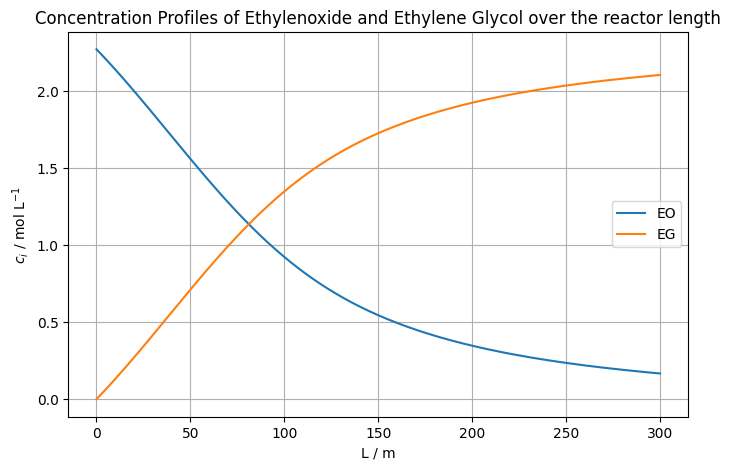

In [423]:
z = sol.t
cEO = sol.y[0]
cEG = sol.y[1]
T = sol.y[2]
X = (cEO0 - cEO) / cEO0

plt.figure(figsize=(8,5))
plt.plot(z, cEO*10**(-3), label='EO')
plt.plot(z, cEG*10**(-3), label='EG')
plt.xlabel('L / m')
plt.ylabel('$c_i$ / mol L$^{-1}$')
plt.title('Concentration Profiles of Ethylenoxide and Ethylene Glycol over the reactor length')
plt.legend()
plt.grid()
plt.show()

The initial concentration of ethylene oxide decreases exponentially with the reactor length due to the reaction. The concentration of ethylene glycol increases accordingly. The exponential trend is characteristic for a first order reaction. 

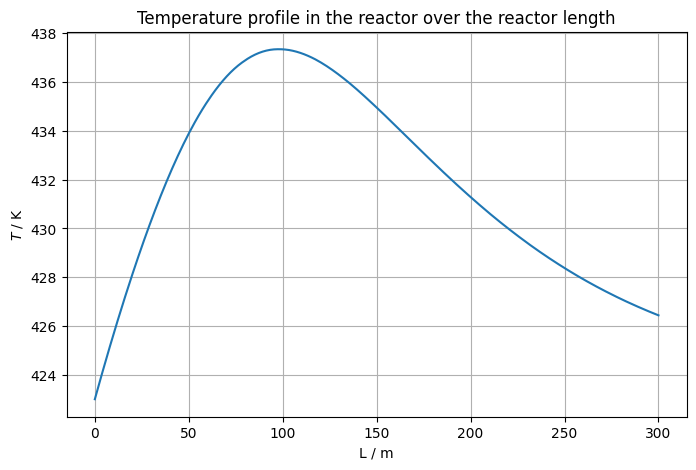

In [424]:
plt.figure(figsize=(8,5))
plt.plot(z, T)
plt.xlabel('L / m')
plt.ylabel('$T$ / K')
plt.title('Temperature profile in the reactor over the reactor length')
plt.grid()
plt.show()

The temperature in the reactor initially increases since the heat generated by the reaction exceeds the heat transferred to the reactor wall. After around 100 m it reaches a maximum of around 437 K. Here the generated heat is as high as the heat transfered. After that, the temperature in the reactor decreases. This is because of the lower EO concentration with the reactor length. This results in a decreasing reaction rate and decreasing generated heat. The transferred heat through the wall exceeds this.

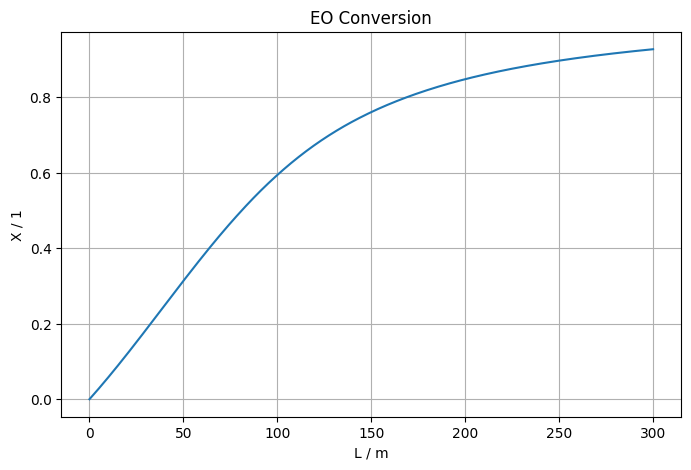

In [425]:
plt.figure(figsize=(8,5))
plt.plot(z, X)
plt.xlabel('L / m')
plt.ylabel('X / 1')
plt.title('EO Conversion')
plt.grid()
plt.show()

The conversion of ethylene oxide rises with the reactor length, since more of the reaction mixture is converted and no further reactions are assumed.

In the following a heat map is generated, where the influence of the reactor length and the wall temperature on the conversion is investigated.

In [426]:
# Heatmap: EO conversion as a function of reactor length and wall temperature 

# Save original values
L_base = L
Twall_base = Twall

# Range of variables
L_values = np.linspace(50, 600, 25)
Twall_values = np.linspace(380, 460, 25)

# Matrix for conversion
X_heat = np.zeros((len(Twall_values), len(L_values)))

for i, Twall_case in enumerate(Twall_values):

    Twall = Twall_case

    for j, L_case in enumerate(L_values):

        L = L_case

        # Evaluation points
        z_case = np.linspace(0, L_case, 300)

        # Initial conditions
        y0_case = [cEO0, cEG0, Tin]

        # Solve reactor
        sol_case = solve_ivp(
            PFTR,
            [0, L_case],
            y0_case,
            method='BDF',
            t_eval=z_case
        )

        # Final conversion
        X_case = (cEO0 - sol_case.y[0]) / cEO0

        X_heat[i, j] = X_case[-1]

# Restore original values
L = L_base
Twall = Twall_base

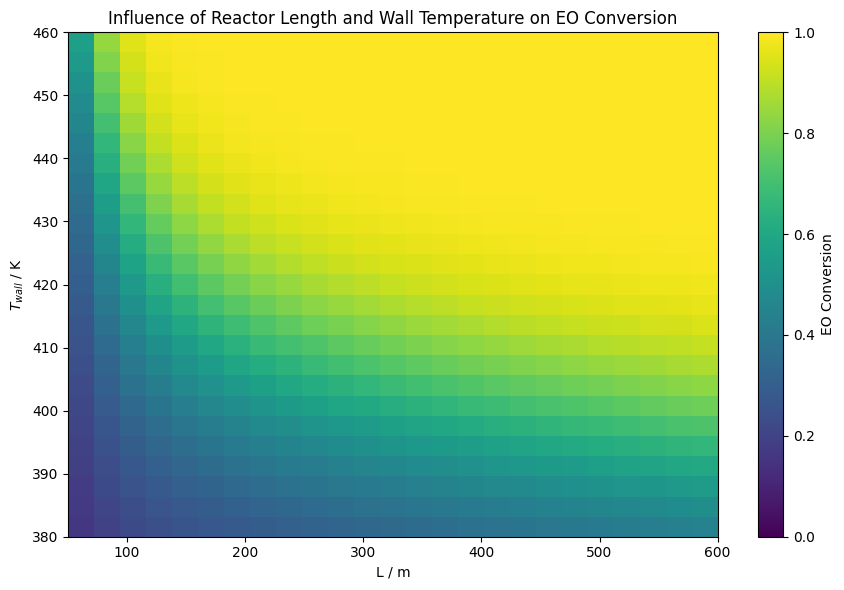

In [427]:
plt.figure(figsize=(9,6))

im = plt.imshow(
    X_heat,
    origin='lower',
    aspect='auto',
    extent=[
        L_values.min(),
        L_values.max(),
        Twall_values.min(),
        Twall_values.max()
    ],
    cmap='viridis',
    vmin=0,
    vmax=1
)

cbar = plt.colorbar(im)
cbar.set_label('EO Conversion')

plt.xlabel('L / m')
plt.ylabel(r'$T_{wall}$ / K')

plt.title('Influence of Reactor Length and Wall Temperature on EO Conversion')

plt.tight_layout()
plt.show()

## 3. Verification Checks

In the following the verification is checked. Since the stoichiometric coefficients of EO and EG are the same, the final concentration should be as high as the initial EO concentration. Furthermore, the conversion should not exceed 1 and the final temperature should not be lower than the inlet and wall temperature.

In [428]:
print(f'Final conversion = {X[-1]:.4f}')
print(f'Final temperature = {T[-1]:.2f} K')
print(f'EO outlet = {cEO[-1]:.2f} mol/m³')
print(f'EG outlet = {cEG[-1]:.2f} mol/m³')
print(f'Initial total concentration = {cEO[0] + cEG[0]:.2f} mol/m³')
print(f'Final total concentration = {(cEO[-1] + cEG[-1]):.2f} mol/m³')

Final conversion = 0.9265
Final temperature = 426.44 K
EO outlet = 166.91 mol/m³
EG outlet = 2103.09 mol/m³
Initial total concentration = 2270.00 mol/m³
Final total concentration = 2270.00 mol/m³


## 4. Sensitivity Analysis

In the following a sensitivity analysis is done. Therefore parameters like the inlet temperature, fluid velocity and the reactor length are varied.

In [429]:
def reset_base_case():

    global Tin, u, L, dR, hwall
    global A_cross, A_wall_per_length
    global zeval, y0

    Tin = 423
    u = 1.0
    L = 300
    dR = 0.03
    hwall = 0.5e3

    A_cross = np.pi*dR**2/4
    A_wall_per_length = np.pi*dR

    zeval = np.linspace(0, L, 300)

    y0 = np.array([cEO0, cEG0, Tin])

### 4.1 Inlet Temperature and Reactor Length

First, the inlet temperature and the reactor length are varied and their influence on the conversion is studied.

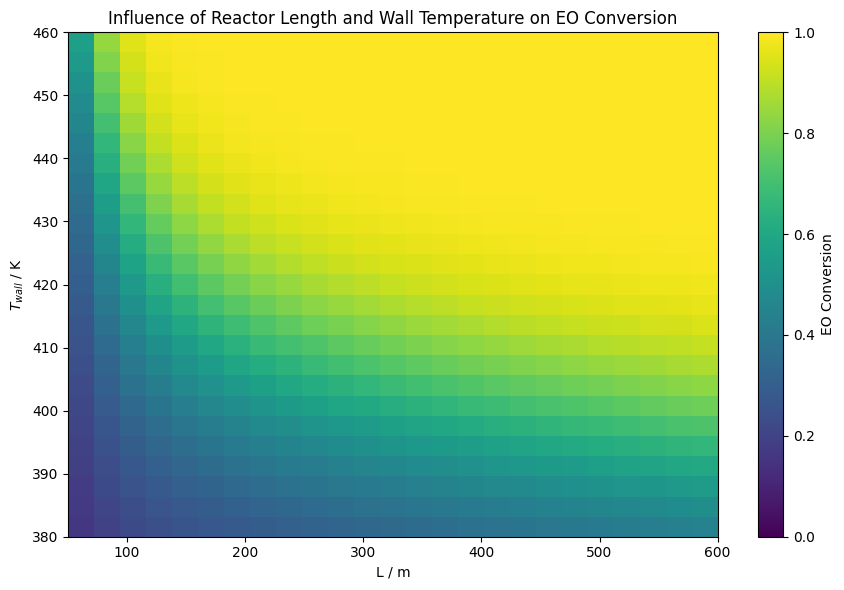

In [430]:
# Heatmap: EO conversion as a function of reactor length and wall temperature 

# Save original values
L_base = L
Twall_base = Twall

# Range of variables
L_values = np.linspace(50, 600, 25)
Twall_values = np.linspace(380, 460, 25)

# Matrix for conversion
X_heat = np.zeros((len(Twall_values), len(L_values)))

for i, Twall_case in enumerate(Twall_values):

    Twall = Twall_case

    for j, L_case in enumerate(L_values):

        L = L_case

        # Evaluation points
        z_case = np.linspace(0, L_case, 300)

        # Initial conditions
        y0_case = [cEO0, cEG0, Tin]

        # Solve reactor
        sol_case = solve_ivp(
            PFTR,
            [0, L_case],
            y0_case,
            method='BDF',
            t_eval=z_case
        )

        # Final conversion
        X_case = (cEO0 - sol_case.y[0]) / cEO0

        X_heat[i, j] = X_case[-1]

# Restore original values
L = L_base
Twall = Twall_base

plt.figure(figsize=(9,6))

im = plt.imshow(
    X_heat,
    origin='lower',
    aspect='auto',
    extent=[
        L_values.min(),
        L_values.max(),
        Twall_values.min(),
        Twall_values.max()
    ],
    cmap='viridis',
    vmin=0,
    vmax=1
)

cbar = plt.colorbar(im)
cbar.set_label('EO Conversion')

plt.xlabel('L / m')
plt.ylabel(r'$T_{wall}$ / K')

plt.title('Influence of Reactor Length and Wall Temperature on EO Conversion')

plt.tight_layout()
plt.show()

The influence of the wall temperature and the reactor length on the EO conversion are plotted. For lower temperatures around 380 K, the EO conversion is almost zero for a reactor length of around 50 m and rises with a higher wall temperature. This is because of the higher wall temperature, which results in a higher temperature in the reactor and thus a higher reaction rate due to the Arrhenius Law.

### Inlet Temperature

In the following the inlet temperature is varied and the effect of different inlet temperatures is studied. This is done for 400 K, 423 K, 450 K, 473.15 K and 600 K as ann extreme case. The 473.15 K were also used in Onuorah et al. (2019), where the non-catalytic hydrolysis of EO was studied.

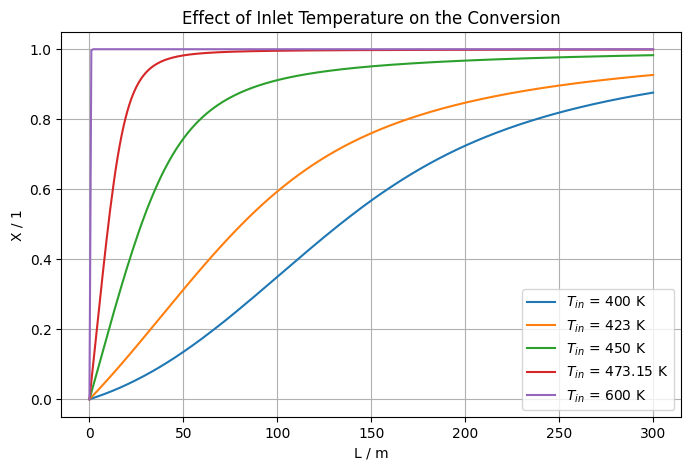

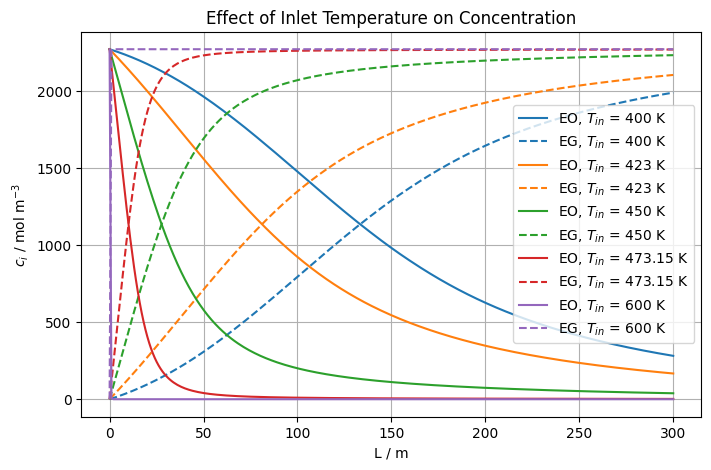

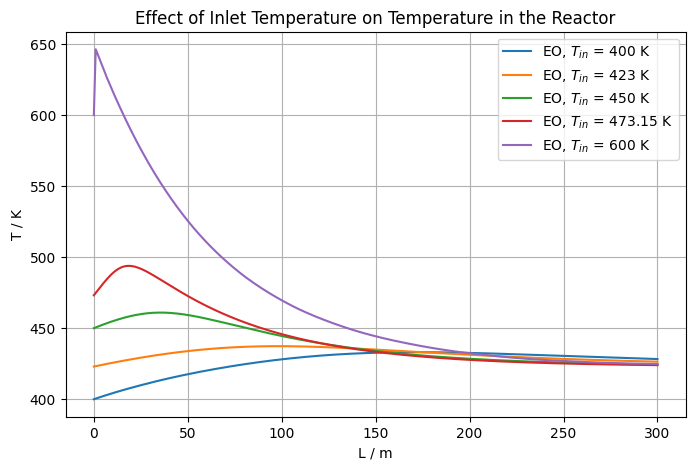

In [431]:
# Reset base case

reset_base_case()

Tin_list = [400, 423, 450, 473.15, 600]

plt.figure(figsize=(8,5))

for Tin_case in Tin_list:
    y0 = [cEO0, cEG0, Tin_case]
    sol_case = solve_ivp(PFTR,[0,L],y0,method='BDF',t_eval=zeval)
    X_case = (cEO0 - sol_case.y[0]) / cEO0
    plt.plot(sol_case.t, X_case, label=f'$T_{{in}}$ = {Tin_case} K')

plt.xlabel('L / m')
plt.ylabel('X / 1')
plt.title('Effect of Inlet Temperature on the Conversion')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8,5))

for Tin_case in Tin_list:

    y0 = [cEO0, cEG0, Tin_case]

    sol_case = solve_ivp(
        PFTR,
        [0, L],
        y0,
        method='BDF',
        t_eval=zeval
    )

    # EO: solid line
    line, = plt.plot(
        sol_case.t,
        sol_case.y[0],
        '-',
        label=f'EO, $T_{{in}}$ = {Tin_case} K'
    )

    # EG: dashed line with same color as EO
    plt.plot(
        sol_case.t,
        sol_case.y[1],
        '--',
        color=line.get_color(),
        label=f'EG, $T_{{in}}$ = {Tin_case} K'
    )

plt.xlabel('L / m')
plt.ylabel(r'$c_i$ / mol m$^{-3}$')
plt.title('Effect of Inlet Temperature on Concentration')
plt.grid(True)
plt.legend()
plt.show()

# Effect of inlet Temperature on Temperature in the reactor

plt.figure(figsize=(8,5))

for Tin_case in Tin_list:

    Tin = Tin_case

    y0 = np.array([cEO0, cEG0, Tin_case])

    sol_case = solve_ivp(
        PFTR,
        [0,L],
        y0,
        method='BDF',
        t_eval=zeval
    )

    plt.plot(sol_case.t,
             sol_case.y[2],
             label=f'EO, $T_{{in}}$ = {Tin_case} K')

plt.xlabel('L / m')
plt.ylabel('T / K')
plt.title('Effect of Inlet Temperature on Temperature in the Reactor')
plt.grid(True)
plt.legend()
plt.show()

u = 1.0

For each case the conversion is increasing because more EO is converted to EG. For higher temperatures the conversion is higher because of the higher reaction rate due to the Arrhenius Law. For an inlet temperature of 600 K the conversion reaches a value of 1 already at the very beginning of the reactor. The EO concentration reaches a value of zero very fast in this case. This correlates indeed with higher operation costs (OPEX), but also leads to lower capital costs (CAPEX) when developing a new reactor. Since all of the initial EO concentration is converted at the beginning, the maximum temperature is also reached at the beginning. Afterwards, the temperature decreases because the reaction is essentially complete and only cooling remains and no heat is generated through reaction. However for low inlet temperatures a higher reactor length is needed to reach a higher conversion.

In [432]:
# Validation

summary = []

for Tin_case in Tin_list:

    y0 = [cEO0, cEG0, Tin_case]

    sol_case = solve_ivp(
        PFTR,
        [0, L],
        y0,
        method='BDF',
        t_eval=zeval
    )

    X_case = (cEO0 - sol_case.y[0]) / cEO0

    summary.append({
        "$T_{in} / K": Tin_case,
        "EO outlet / mol/m³": sol_case.y[0,-1],
        "EG outlet / mol/m³": sol_case.y[1,-1],
        "Outlet Temperature / K": sol_case.y[2,-1],
        "Conversion / %":100*X_case[-1]
    })

df = pd.DataFrame(summary)
display(df.round(2))

,$T_{in} / K,EO outlet / mol/m³,EG outlet / mol/m³,Outlet Temperature / K,Conversion / %
0,400.00,281.36,1988.64,428.29,87.61
1,423.00,166.91,2103.09,426.44,92.65
2,450.00,38.64,2231.36,424.47,98.30
3,473.15,1.99,2268.01,423.98,99.91
4,600.00,-0.00,2270.00,424.76,100.00


### Fluid Velocity

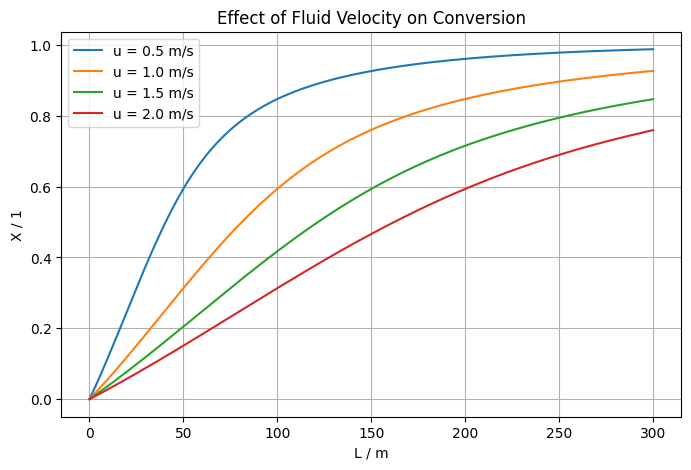

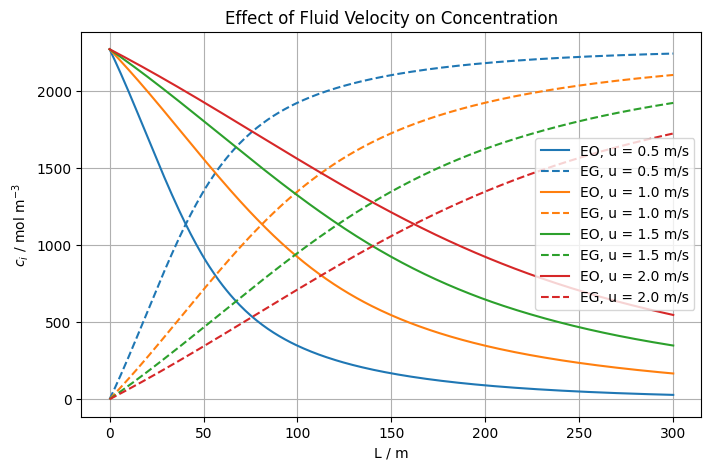

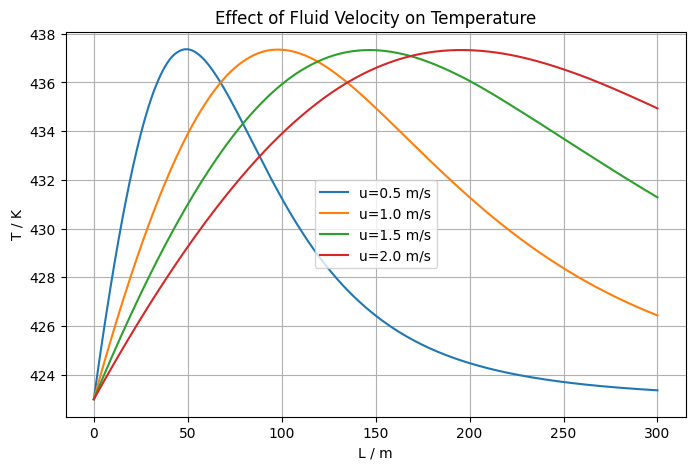

In [433]:
# Reset base case

reset_base_case()

zeval = np.linspace(0, L, 300)

u_list = [0.5, 1.0, 1.5, 2.0]

plt.figure(figsize=(8,5))

for u_case in u_list:

    u = u_case

    y0_case = np.array([cEO0, cEG0, Tin])

    sol_case = solve_ivp(
        PFTR,
        [0, L],
        y0_case,
        method='BDF',
        t_eval=zeval
    )

    X_case = (cEO0 - sol_case.y[0]) / cEO0

    plt.plot(
        sol_case.t,
        X_case,
        label=f'u = {u_case} m/s'
    )

plt.xlabel('L / m')
plt.ylabel('X / 1')
plt.title('Effect of Fluid Velocity on Conversion')
plt.legend()
plt.grid()
plt.show()

u = 1.0

# EO and EG Concentration Profiles

plt.figure(figsize=(8,5))

for u_case in u_list:

    u = u_case

    y0_case = np.array([cEO0, cEG0, Tin])

    sol_case = solve_ivp(
        PFTR,
        [0, L],
        y0_case,
        method='BDF',
        t_eval=zeval
    )

    # EO: solid line
    line, = plt.plot(
        sol_case.t,
        sol_case.y[0],
        '-',
        label=f'EO, u = {u_case} m/s'
    )

    # EG: dashed line with same color as EO
    plt.plot(
        sol_case.t,
        sol_case.y[1],
        '--',
        color=line.get_color(),
        label=f'EG, u = {u_case} m/s'
    )

plt.xlabel('L / m')
plt.ylabel(r'$c_i$ / mol m$^{-3}$')
plt.title('Effect of Fluid Velocity on Concentration')
plt.grid(True)
plt.legend()
plt.show()

# Effect of Fluid Velocity on Temperature

plt.figure(figsize=(8,5))

for u_case in u_list:

    u = u_case

    y0_case = np.array([cEO0, cEG0, Tin])

    sol_case = solve_ivp(
        PFTR,
        [0,L],
        y0_case,
        method='BDF',
        t_eval=zeval
    )

    plt.plot(sol_case.t,
             sol_case.y[2],
             label=f'u={u_case} m/s')

plt.xlabel('L / m')
plt.ylabel('T / K')
plt.title('Effect of Fluid Velocity on Temperature')
plt.grid(True)
plt.legend()
plt.show()

u = 1.0

The conversion increases with a lower fluid velocity. This is due to the higher residence time. Thus more EO can be converted to EG. Also the EO concentration decreases faster for a lower fluid velocity. The maximum temperature in the reactor is for all cases around 437 K, but for lower fluid velocities the maximum is reached earlier. For each case the maximum temperature is reached at a conversion of around 0.58. Since this is reached later for higher fluid velocities, the maximum temperature shifts to the right for higher fluid velocities.

In [434]:
# Validation 

summary = []

for u_case in u_list:

    u = u_case

    sol_case = solve_ivp(
        PFTR,
        [0,L],
        y0,
        method='BDF',
        t_eval=zeval
    )

    X_case = (cEO0-sol_case.y[0])/cEO0

    summary.append({
        "Velocity (m/s)":u_case,
        "EO outlet (mol/m³)":sol_case.y[0,-1],
        "EG outlet (mol/m³)":sol_case.y[1,-1],
        "Outlet Temperature (K)":sol_case.y[2,-1],
        "Conversion (%)":100*X_case[-1]
    })

df=pd.DataFrame(summary)
display(df.round(2))

,Velocity (m/s),EO outlet (mol/m³),EG outlet (mol/m³),Outlet Temperature (K),Conversion (%)
0,0.5,28.14,2241.86,423.37,98.76
1,1.0,166.91,2103.09,426.44,92.65
2,1.5,348.25,1921.75,431.28,84.66
3,2.0,546.52,1723.48,434.94,75.92


### Reactor Length

 In the following the influence of the reactor length on the conversion is investigated.

In [435]:
# Reset base case

reset_base_case()

L_list = [100, 200, 300, 400, 500, 700, 1000, 1500, 2000]

summary = []

for L_case in L_list:

    zeval_case = np.linspace(0, L_case, 300)

    sol_case = solve_ivp(
        PFTR,
        [0, L_case],
        y0,
        method='BDF',
        t_eval=zeval_case
    )

    X_case = (cEO0 - sol_case.y[0,-1]) / cEO0

    summary.append({
        "Reactor Length / m": L_case,
        "EO outlet / mol/m³": sol_case.y[0,-1],
        "EG outlet / mol/m³": sol_case.y[1,-1],
        "Outlet Temperature / K": sol_case.y[2,-1],
        "Conversion / %": 100*X_case
    })

df = pd.DataFrame(summary)

display(df.round(3))

,Reactor Length / m,EO outlet / mol/m³,EG outlet / mol/m³,Outlet Temperature / K,Conversion / %
0,100,922.768,1347.232,437.338,59.349
1,200,346.944,1923.056,431.283,84.716
2,300,166.906,2103.094,426.439,92.647
3,400,89.405,2180.595,424.477,96.061
4,500,49.741,2220.259,423.704,97.809
5,700,15.964,2254.036,423.199,99.297
6,1000,2.974,2267.026,423.036,99.869
7,1500,0.181,2269.819,423.002,99.992
8,2000,0.011,2269.989,423.000,100.000


For a reactor length of 500 m, a conversion of around 99 % is reached. A further increase in the length does not lead to an improvemnt of the conversion. Therefore, it should be evaluated whether the additional capital cost associated with a longer reactor are justified by the increased ethylene glycol production. 

### 4.4. Heat Transfer Coefficient

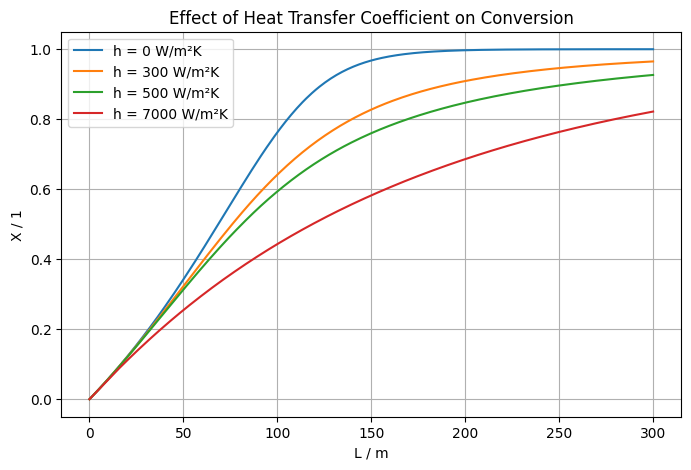

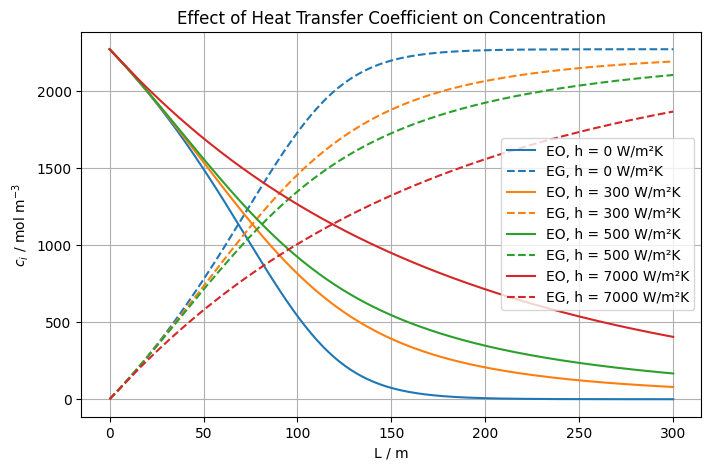

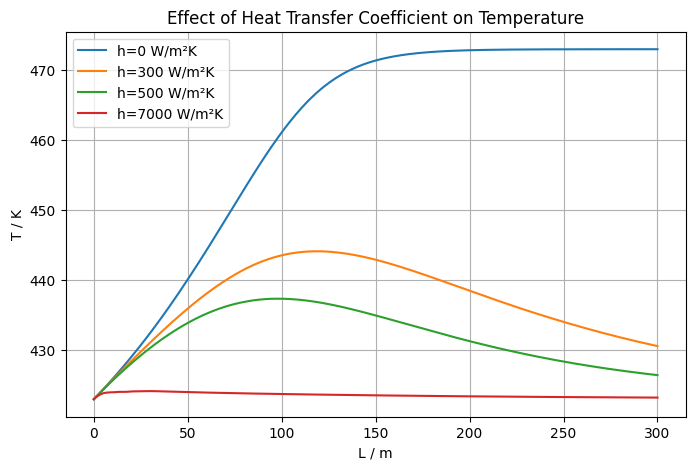

In [436]:
# Reset base case

reset_base_case()

hwall_list = [0, 300, 500, 7000]

plt.figure(figsize=(8,5))

for h_case in hwall_list:

    hwall = h_case

    sol_case = solve_ivp(
        PFTR,
        [0, L],
        y0,
        method='BDF',
        t_eval=zeval
    )

    X_case = (cEO0 - sol_case.y[0]) / cEO0

    plt.plot(
        sol_case.t,
        X_case,
        label=f'h = {h_case} W/m²K'
    )

plt.xlabel('L / m')
plt.ylabel('X / 1')
plt.title('Effect of Heat Transfer Coefficient on Conversion')
plt.legend()
plt.grid()
plt.show()

# EO and EG Concentration Profiles

plt.figure(figsize=(8,5))

for h_case in hwall_list:

    hwall = h_case

    sol_case = solve_ivp(
        PFTR,
        [0, L],
        y0,
        method='BDF',
        t_eval=zeval
    )

    # EO: solid line
    line, = plt.plot(
        sol_case.t,
        sol_case.y[0],
        '-',
        label=f'EO, h = {h_case} W/m²K'
    )

    # EG: dashed line with same color as EO
    plt.plot(
        sol_case.t,
        sol_case.y[1],
        '--',
        color=line.get_color(),
        label=f'EG, h = {h_case} W/m²K'
    )

plt.xlabel('L / m')
plt.ylabel(r'$c_i$ / mol m$^{-3}$')
plt.title('Effect of Heat Transfer Coefficient on Concentration')
plt.grid(True)
plt.legend()
plt.show()

# Effect of Heat Transfer Coefficient on Temperature

plt.figure(figsize=(8,5))

for h_case in hwall_list:

    hwall = h_case

    sol_case = solve_ivp(
        PFTR,
        [0,L],
        y0,
        method='BDF',
        t_eval=zeval
    )

    plt.plot(sol_case.t,
             sol_case.y[2],
             label=f'h={h_case} W/m²K')

plt.xlabel('L / m')
plt.ylabel('T / K')
plt.title('Effect of Heat Transfer Coefficient on Temperature')
plt.grid(True)
plt.legend()
plt.show()

hwall = 0.5e3

The temperature in the reactor is lower for a high heat transfer coefficient due to a fast heat transfer with the reactor wall. This results in a lower reaction rate and thus higher EO concentration in the reactor. The conversion is lowest for a high heat transfer coefficient. 
For the boundary case h = 0 W/m$^2$K, where there is no heat transfer with the wall, the conversion is the highest due to the higher reactor temperature and thus higher reaction rate. When the maximum conversion is reached, the temperature stays constant since no heat is generated or transfered anymore.

In [437]:
# Validation 

summary=[]

for h_case in hwall_list:

    hwall=h_case

    sol_case=solve_ivp(
        PFTR,
        [0,L],
        y0,
        method='BDF',
        t_eval=zeval
    )

    X_case=(cEO0-sol_case.y[0])/cEO0

    summary.append({
        "h (W/m²K)":h_case,
        "EO outlet (mol/m³)":sol_case.y[0,-1],
        "EG outlet (mol/m³)":sol_case.y[1,-1],
        "Outlet Temperature (K)":sol_case.y[2,-1],
        "Conversion (%)":100*X_case[-1]
    })

df=pd.DataFrame(summary)
display(df.round(2))

,h (W/m²K),EO outlet (mol/m³),EG outlet (mol/m³),Outlet Temperature (K),Conversion (%)
0,0,0.05,2269.95,472.95,100.00
1,300,79.28,2190.72,430.58,96.51
2,500,166.91,2103.09,426.44,92.65
3,7000,404.29,1865.71,423.23,82.19


### Reactor Diameter

In the following the reactor diameter is varied.

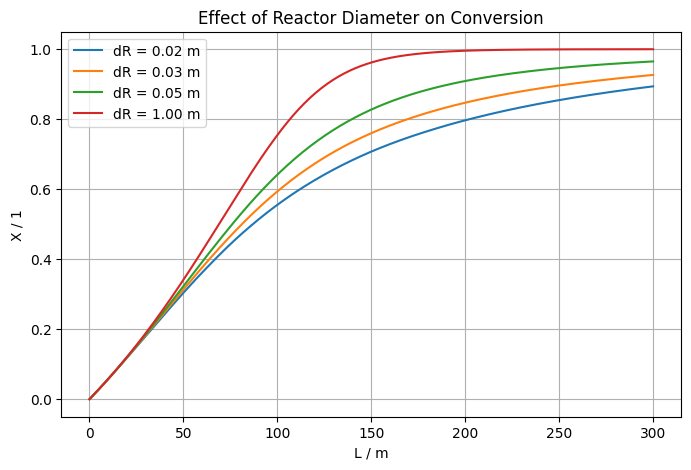

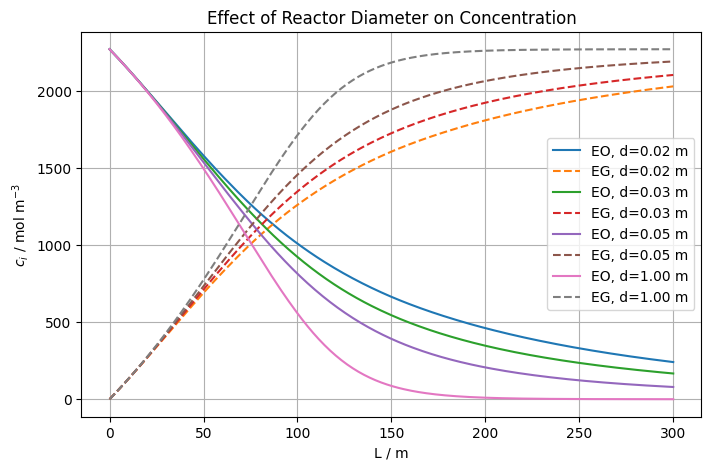

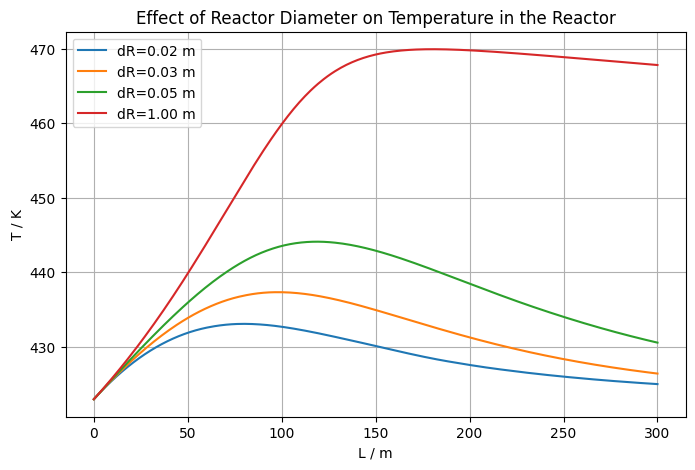

In [438]:
# Reset base case

reset_base_case()

dR_list = [0.02, 0.03, 0.05, 1]  # m

plt.figure(figsize=(8,5))

for dR_i in dR_list:

    dR = dR_i

    #Geometric relations
    A_cross = np.pi*dR**2/4
    A_wall_per_length = np.pi*dR
    
    sol = solve_ivp(
        PFTR,
        [0, L],
        y0,
        method='BDF',
        t_eval=zeval
    )

    X_temp = (cEO0 - sol.y[0]) / cEO0

    plt.plot(zeval, X_temp, label=f"dR = {dR_i:.2f} m")

plt.xlabel("L / m")
plt.ylabel("X / 1")
plt.title("Effect of Reactor Diameter on Conversion")
plt.legend()
plt.grid()
plt.show()

# EO and EG Concentration Profiles

plt.figure(figsize=(8,5))

for dR_i in dR_list:

    dR = dR_i

    A_cross = np.pi*dR**2/4
    A_wall_per_length = np.pi*dR

    sol_case = solve_ivp(
        PFTR,
        [0,L],
        y0,
        method='BDF',
        t_eval=zeval
    )

    plt.plot(sol_case.t,
             sol_case.y[0],
             label=f'EO, d={dR_i:.2f} m')

    plt.plot(sol_case.t,
             sol_case.y[1],
             '--',
             label=f'EG, d={dR_i:.2f} m')

plt.xlabel('L / m')
plt.ylabel(r'$c_i$ / mol m$^{-3}$')
plt.title('Effect of Reactor Diameter on Concentration')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8,5))

for dR_i in dR_list:

    dR = dR_i
    A_cross = np.pi*dR**2/4
    A_wall_per_length = np.pi*dR

    sol = solve_ivp(
        PFTR,
        [0,L],
        y0,
        method='BDF',
        t_eval=z
    )

    plt.plot(z, sol.y[2], label=f"dR={dR_i:.2f} m")

plt.xlabel("L / m")
plt.ylabel("T / K")
plt.title("Effect of Reactor Diameter on Temperature in the Reactor")
plt.legend()
plt.grid()
plt.show()

A higher reactor diameter results in a higher conversion because the heat transfer with the wall is worse. This results in higher temperatures in the reactor and thus higher reaction rates.

In [439]:
# Validation

summary=[]

for dR_case in dR_list:

    dR=dR_case

    A_cross=np.pi*dR**2/4
    A_wall_per_length=np.pi*dR

    sol_case=solve_ivp(
        PFTR,
        [0,L],
        y0,
        method='BDF',
        t_eval=zeval
    )

    X_case=(cEO0-sol_case.y[0])/cEO0

    summary.append({
        "Diameter (m)":dR_case,
        "EO outlet (mol/m³)":sol_case.y[0,-1],
        "EG outlet (mol/m³)":sol_case.y[1,-1],
        "Outlet Temperature (K)":sol_case.y[2,-1],
        "Conversion (%)":100*X_case[-1]
    })

df=pd.DataFrame(summary)
display(df.round(2))

,Diameter (m),EO outlet (mol/m³),EG outlet (mol/m³),Outlet Temperature (K),Conversion (%)
0,0.02,240.93,2029.07,425.03,89.39
1,0.03,166.91,2103.09,426.44,92.65
2,0.05,79.28,2190.72,430.58,96.51
3,1.00,0.15,2269.85,467.79,99.99


Increasing the reactor diameter leads to higher EO conversion and higher EG production. This behavior is mainly explained by the lower surface-to-volume ratio of the reactor. As the diameter increases, heat exchange with the reactor wall becomes less effective, allowing the reaction mixture to reach higher temperatures. Since the hydration of ethylene oxide is strongly temperature-dependent, the higher reactor temperature increases the reaction rate and therefore the final conversion.

## 5. Results and Discussion

In the simulation it was shown that high inlet temperatures and higher wall temperatures or lower heat transfer coefficients can be beneficial to reach a high conversion even for low reaction rates. But for high temperatures additional safety precautions have to be made. Furthermore a higher pressure is needed to have liquid operating conditions. 
For a high conversion a longer reactor is also a possible solution. For reactor design it must be considered, that the reactor length should not be increased upon the point, where a plateau in the conversion is reached. Depending on separation costs and EG price for selling, it could be senseful to design the reactor in a way, that a conversion lower than 1 is reached.
In this case we have a trade of between CAPEX for high temperatures and OPEX for the reactor length.

The presented model could be optimized by taking side reactions and consecutive reactions into account, like the reaction of EO with EG to Diethylene Glycol or higher Glycols [4]. Furthermore an economical analysis can be done. 

For optimizing the process a rectification distillation column could be used, as it was studied by Othman et al. (2024), which can result in a higher EG yield, lower requirement of EO in the feed and lower energy costs for the separation [5].



## 6. Summary Table

In [440]:
print("Case Summary")
print("--------------------------")
print(f"Final Conversion = {X[-1]:.4f}")
print(f"Final Temperature = {T[-1]:.2f} K")
print(f"EO Outlet Concentration = {cEO[-1]:.2f} mol/m³")
print(f"EG Outlet Concentration = {cEG[-1]:.2f} mol/m³")

Case Summary
--------------------------
Final Conversion = 0.9265
Final Temperature = 426.44 K
EO Outlet Concentration = 166.91 mol/m³
EG Outlet Concentration = 2103.09 mol/m³


## 7. Overall Assessment

The sensitivity analyses consistently showed that the reactor model responds according to the expected physical and chemical principles. Changes in inlet temperature, reactor length, fluid velocity and reactor diameter produced systematic variations in conversion, concentration profiles and outlet temperature that agree with the kinetic and transport phenomena governing ethylene oxide hydration. The obtained trends are consistent with the literature, confirming that the implemented model provides a realistic representation of the process (Melhem et al., 1995; Cocuzza et al., 1975).

Although the reactor considered in this assignment is simplified compared with industrial tubular reactors, the model successfully captures the main effects of the operating parameters on reactor performance. This demonstrates that the mathematical implementation is suitable for investigating process behavior and for evaluating the influence of design and operating variables during the preliminary stages of reactor design.

## 8. Industrial Relevance

Ethylene glycol is a bulk chemical of major‌ industrial importance․ Ethylene glycol is produced from the hydrolysis of ethylene oxide and is used‌ mainly for PET resins and polyester fibers․ These in turn are used to make plastic bottles‚ food packaging‚ textiles‚ carpets‚‌ and other polymer-based products․ Ethylene glycol production is especially important in‌ the polymer‚ packaging‚ and textile industries․ Ethylene glycol is also used as a base fluid for antifreeze and coolant formulations‚ which lower the temperature at which the fluid freezes and broaden‌ the operating temperature range of the fluid․ Antifreeze is used where coolants are used‚ such as in automotive and industrial heat-transfer systems and in‌ de-icing of transportation and aviation systems․ Thus‚ ethylene glycol production is‌ essential not only for the chemical manufacturing industry‚ but also for the energy‚ transport‚ and materials industries․ [6]

Their performance can be characterized by factors like selectivity, activity, productivity and stability. In general the EG is produced in a standard theremal glycol reaction process. In this EO and water react at a temperature of around 200 °C and elevated pressure without a catalyst to EG with a monoethylene yield of about 90 - 92 %. The side products are  heavier glycols like diethylene glycol and triethylene glycol. Excess water can be used to minimize side product and consecutive product formation. After that the excess water of the water-glycol mixture is recovered and recycled in multiple evaporators. The further separation of the glycols happens through distillation into monoethylene glycol (in this report EG) and higher glycols. In recent technologies in a first step EO is converted with $CO_2$ to ethylene carbonate (EC). After that EC reacts with water to EG. Both reactions are catalysed mostly with silver-based catalysts. Since the second step, the reaction to EG, happens under the absence of EO, the formation of higher glycols can be minimised and a EG yield of around 99 % can be achieved. [7]

In [441]:
print("Software Versions")
print("-----------------")
print(f"Python      : {sys.version.split()[0]}")
print(f"NumPy       : {np.__version__}")
print(f"Matplotlib  : {matplotlib.__version__}")
print(f"Pandas      : {pd.__version__}")

Software Versions
-----------------
Python      : 3.12.3
NumPy       : 1.26.4
Matplotlib  : 3.10.3
Pandas      : 2.2.2


## 9. Conclusion

A plug flow tubular reactor model for the hydration of ethylene oxide was successfully implemented using coupled mass and energy balances. The calculated concentration, temperature and conversion profiles showed the expected behavior for an exothermic reaction and were found to be consistent with the literature.

The performed sensitivity analyses demonstrated that the inlet temperature has the largest influence on reactor performance because it directly affects the reaction kinetics. Reactor length, fluid velocity and reactor diameter also modify the conversion through changes in residence time and heat transfer, although their impact is less pronounced within the investigated operating range.

Overall, the implemented model provides a reliable tool for studying the influence of operating conditions on reactor behavior. Such analyses are useful during preliminary reactor design, where understanding the interaction between kinetic and transport phenomena is essential before moving to more detailed industrial reactor models.

## 10. AI Usage

## References

[1] L. Ding, J. Tang, X. Qiao, C. Liu, Y. Xue, G. Wu, Design and analysis of an intensified column with side reactor configuration for ethylene glycol production from ethylene oxide, Chemical Engineering and Processing - Process Intensification 147 (2020) 107744. https://doi.org/10.1016/j.cep.2019.107744.

[2] H.S. Fogler, Elements of chemical reaction engineering, Fifth edition, Prentice Hall, Boston, 2016.

[3] R. Güttel, T. Turek, Chemische Reaktionstechnik, Springer Berlin Heidelberg, Berlin, Heidelberg, 2021. https://doi.org/10.1007/978-3-662-63150-8.

[4] G.A. Melhem, A. Gianetto, M.E. Levin, H.G. Fisher, S. Chippett, S.K. Singh, P.I. Chipman, Kinetics of the reactions of ethylene oxide with water and ethylene glycols, Process Safety Progress 20 (2001) 231–246. https://doi.org/10.1002/prs.680200405.

[5] J. Othman, Process Modelling and Simulation of Reactive Distillation for the Synthesis of High Purity Mono Ethylene Glycol, PPS 6 (2024). https://doi.org/10.31031/PPS.2024.06.000637.

[6] Ethylene Glycol, Chemical Safety Facts (n.d.). https://www.chemicalsafetyfacts.org/chemicals/ethylene-glycol/ (accessed June 28, 2026).

[7] Han van Milligen, Brian VanderWilp, Gary J. (Jimmy) Wells, Enhancements in ethylene oxide/ethylene glycol manufacturing technology, (n.d.). https://catalysts.shell.com/hubfs/Content%20Library/SCT%20-%20Enhancements%20in%20EOEG%20Manufacturing%20Technology.pdf (accessed June 28, 2026).

[8] Cocuzza, E., Cicerone, D. S., & Santacesaria, E. (1975). *Ethylene glycol production by hydration of ethylene oxide: Industrial reactor design and operating conditions*. *Chemical Engineering Science, 30*(10), 1285–1292.

[9] Othman, N., Al-Hajri, R., & Elbashir, N. O. (2024). *Process intensification for ethylene glycol production using reactive distillation: A simulation study*. *Chemical Engineering and Processing: Process Intensification, 197*, 109709.
